In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
## make tensorflow lstm model ##
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Dropout, LSTM, Input, Activation, concatenate, Bidirectional
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import optimizers
from tensorflow.keras import backend as K
from tensorflow.keras import regularizers

2025-02-24 19:46:29.824565: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
## load data ##
imu = pd.read_csv('../Groves/imu_data.csv')
true_data = pd.read_csv('../Groves/true_data.csv')

In [4]:
imu = imu.to_numpy()
true_data = true_data.to_numpy()

In [15]:
x_train = (imu+np.array([0, 0, 9.8, 0, 0, 0]))*10
x_train.shape

(6000, 6)

In [39]:
y_train =(true_data[:, 1:])
y_train.shape

(6000, 9)

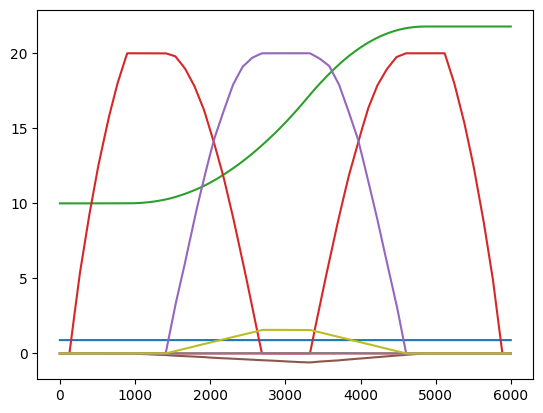

In [40]:
plt.plot(y_train)

In [17]:
# function make x train data with 10 sequence
def make_x_train(x_train_, x_train1_, sequence_length):
    x_result = []
    x_result1 = []
    for index in range(len(x_train_) - sequence_length):
        x_result.append(x_train_[index: index + sequence_length])
        x_result1.append(x_train1_[index])
    return np.array(x_result), np.array(x_result1)

x_train, x_train1 = make_x_train(x_train, y_train, 10)
x_train.shape

(5990, 10, 6)

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_7 (InputLayer)        [(None, 10, 6)]              0         []                            
                                                                                                  
 input_8 (InputLayer)        [(None, 9, 1)]               0         []                            
                                                                                                  
 lstm_12 (LSTM)              (None, 10, 32)               4992      ['input_7[0][0]']             
                                                                                                  
 lstm_14 (LSTM)              (None, 9, 32)                4352      ['input_8[0][0]']             
                                                                                            

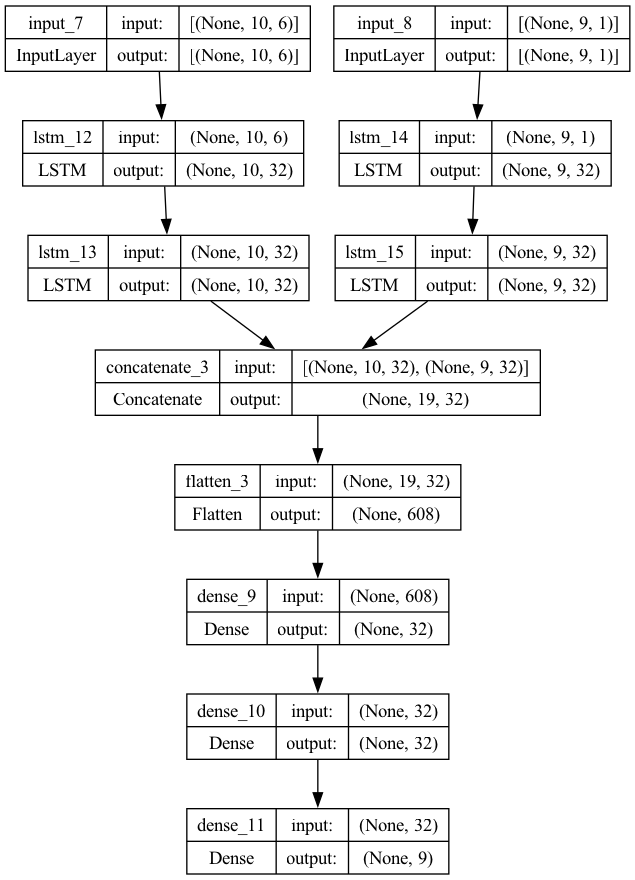

In [35]:
# net work with two different input
def lstm_model(x_train, x_train1, y_train):
    input_1 = Input(shape=(x_train.shape[1], x_train.shape[2]))
    input_2 = Input(shape=(x_train1.shape[1], 1))

    lstm_1 = LSTM(32, return_sequences=True)(input_1)
    lstm_1 = LSTM(32, return_sequences=True)(lstm_1)

    lstm_2 = LSTM(32, return_sequences=True)(input_2)
    lstm_2 = LSTM(32, return_sequences=True)(lstm_2)

    lstm_3 = concatenate([lstm_1, lstm_2], axis=1)
    # output to one dimension
    lstm_3 = layers.Flatten()(lstm_3)
    lstm_3 = Dense(32, activation='linear')(lstm_3)
    lstm_3 = Dense(32, activation='linear', kernel_regularizer=regularizers.l2(0.01))(lstm_3)

    lstm_3 = Dense(y_train.shape[1], activation='linear')(lstm_3)


    # return model
    return Model(inputs=[input_1, input_2], outputs=lstm_3)

# example
model = lstm_model(x_train, x_train1, y_train)
model.summary()
# plot model
tf.keras.utils.plot_model(model, to_file='model.png', show_shapes=True)

In [30]:
# load model
# model.load_weights('model.h5')

In [36]:
x_train = tf.convert_to_tensor(x_train, dtype=tf.float32)
x_train1 = tf.convert_to_tensor(x_train1, dtype=tf.float32)
y_train = tf.convert_to_tensor(y_train, dtype=tf.float32)

# compile model
model.compile(loss='mse', optimizer='adam', metrics=['mse'])

# early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, verbose=1)

# save model
model_path = 'model_car.h5'

In [37]:
print(model)

In [38]:
with tf.device('/device:GPU:0'):
    history = model.fit([x_train, x_train1], y_train, epochs=100, batch_size=128, validation_split=0.2)

Epoch 1/100
38/38 [==============================] - 8s 49ms/step - loss: 611710.5000 - mse: 611710.3125 - val_loss: 699409.6875 - val_mse: 699409.3125
Epoch 2/100
38/38 [==============================] - 1s 17ms/step - loss: 307322.8750 - mse: 307322.5938 - val_loss: 393016.0938 - val_mse: 393015.6250
Epoch 3/100
38/38 [==============================] - 1s 17ms/step - loss: 164713.1250 - mse: 164712.6562 - val_loss: 348379.8750 - val_mse: 348379.4375
Epoch 4/100
38/38 [==============================] - 1s 17ms/step - loss: 153264.6875 - mse: 153264.2344 - val_loss: 339139.0312 - val_mse: 339138.5625
Epoch 5/100
38/38 [==============================] - 1s 17ms/step - loss: 142207.2656 - mse: 142206.8125 - val_loss: 328048.4688 - val_mse: 328048.0000
Epoch 6/100
38/38 [==============================] - 1s 16ms/step - loss: 140066.0469 - mse: 140065.5625 - val_loss: 329029.9375 - val_mse: 329029.4688
Epoch 7/100
38/38 [==============================] - 1s 16ms/step - loss: 139513.7969 - 

KeyboardInterrupt: 

In [45]:
model.load_weights('LSTM_car.h5')

In [46]:
model.save('LSTM_car')

INFO:tensorflow:Assets written to: LSTM_car/assets


INFO:tensorflow:Assets written to: LSTM_car/assets
